In [5]:
import os
import json
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as F

class CustomCOCODataset(Dataset):
    def __init__(self, root_dir, annotation_file):
        """
        Args:
            root_dir (str): Path to the directory containing the images (e.g., 'train/').
            annotation_file (str): Path to the COCO JSON annotation file.
        """
        self.root_dir = root_dir
        
        # Load the JSON file
        with open(annotation_file, 'r') as f:
            self.coco_data = json.load(f)
        
        self.images = self.coco_data['images']
        self.annotations = self.coco_data['annotations']
        
        # Map each image ID to its corresponding annotations for faster lookup
        self.img_to_anns = {}
        for ann in self.annotations:
            img_id = ann['image_id']
            if img_id not in self.img_to_anns:
                self.img_to_anns[img_id] = []
            self.img_to_anns[img_id].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_id = img_info['id']
        
        # 1. Load the Image
        img_path = os.path.join(self.root_dir, img_info['file_name'])
        image = Image.open(img_path).convert("RGB")
        image = F.to_tensor(image) # Converts to [C, H, W] and normalizes to 0-1
        
        # 2. Get Annotations for this image
        anns = self.img_to_anns.get(img_id, [])
        
        boxes = []
        labels = []
        areas = []
        iscrowd = []
        
        for ann in anns:
            # COCO format: [x_min, y_min, width, height]
            x_min, y_min, w, h = ann['bbox']
            
            # Convert to Faster R-CNN format: [x_min, y_min, x_max, y_max]
            x_max = x_min + w
            y_max = y_min + h
            
            boxes.append([x_min, y_min, x_max, y_max])
            labels.append(ann['category_id']) 
            areas.append(ann['area'])
            iscrowd.append(ann.get('iscrowd', 0)) # Default to 0 if not present
            
        # 3. Convert lists to PyTorch Tensors
        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            areas = torch.as_tensor(areas, dtype=torch.float32)
            iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)
        else:
            # Handle images with no objects (background only)
            boxes = torch.empty((0, 4), dtype=torch.float32)
            labels = torch.empty((0,), dtype=torch.int64)
            areas = torch.empty((0,), dtype=torch.float32)
            iscrowd = torch.empty((0,), dtype=torch.int64)
            
        # 4. Construct the target dictionary
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = torch.tensor([img_id])
        target["area"] = areas
        target["iscrowd"] = iscrowd
        
        return image, target

In [7]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [8]:
# Setup Paths (Adjust these if your JSON files are named differently)
train_dir = 'train/'
train_json = 'train/_annotations.coco.json'

valid_dir = 'valid/'
valid_json = 'valid/_annotations.coco.json'

# Create Dataset objects
dataset_train = CustomCOCODataset(root_dir=train_dir, annotation_file=train_json)
dataset_valid = CustomCOCODataset(root_dir=valid_dir, annotation_file=valid_json)

# Create DataLoaders
# Batch size of 4 is a safe starting point for an RTX 5060 depending on image resolution
data_loader_train = DataLoader(
    dataset_train, 
    batch_size=4, 
    shuffle=True, 
    num_workers=0, 
    collate_fn=collate_fn
)

data_loader_valid = DataLoader(
    dataset_valid, 
    batch_size=4, 
    shuffle=False, 
    num_workers=0, 
    collate_fn=collate_fn
)

print(f"Loaded {len(dataset_train)} training images and {len(dataset_valid)} validation images.")

Loaded 4290 training images and 409 validation images.


In [9]:
import json
import torch
import torchvision
from torchvision.models.detection.fcos import FCOSClassificationHead

# 1. Dynamically find the number of classes from your JSON
with open('train/_annotations.coco.json', 'r') as f:
    coco_data = json.load(f)
    
# Count the categories in the JSON and add 1 for the background class
num_classes = len(coco_data['categories']) + 1 
print(f"Total num_classes (including background): {num_classes}")

# 2. Initialize the FCOS Model
def get_fcos_model(num_classes):
    # Load the pre-trained FCOS model (trained on the standard 91 COCO classes)
    model = torchvision.models.detection.fcos_resnet50_fpn(weights="DEFAULT")
    
    # FCOS has 3 heads (Classification, BBox, and Centerness). 
    # We only need to replace the Classification Head for our custom classes.
    in_channels = model.head.classification_head.cls_logits.in_channels
    num_anchors = model.head.classification_head.num_anchors # FCOS uses 1 anchor
    
    # Swap out the pre-trained head for a fresh one with our class count
    model.head.classification_head = FCOSClassificationHead(
        in_channels=in_channels, 
        num_anchors=num_anchors, 
        num_classes=num_classes
    )
    
    return model

# 3. Push to RTX 5060
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Initializing FCOS on device: {device}")

fcos_model = get_fcos_model(num_classes).to(device)

# 4. Setup Optimizer
# Note: FCOS can be a bit more sensitive than Faster R-CNN, so we lower the Learning Rate to 0.001
params = [p for p in fcos_model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0001)
scaler = torch.amp.GradScaler('cuda')

# 5. The Training Loop
num_epochs = 10 

for epoch in range(num_epochs):
    fcos_model.train()
    epoch_loss = 0
    
    for batch_idx, (images, targets) in enumerate(data_loader_train):
        # Move images and targets to GPU
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            # FCOS returns a dictionary of losses: classification, bbox_regression, and bbox_ctrness
            loss_dict = fcos_model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
        
        # Backpropagation
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += losses.item()
        
        if batch_idx % 50 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | Batch [{batch_idx}/{len(data_loader_train)}] | FCOS Loss: {losses.item():.4f}")
            
    print(f"--- Epoch {epoch+1} Completed | Average Loss: {epoch_loss/len(data_loader_train):.4f} ---")

print("FCOS Training Complete!")

# Save the new FCOS weights
torch.save(fcos_model.state_dict(), "fcos_custom_weights.pth")

Total num_classes (including background): 6
Initializing FCOS on device: cuda
Epoch [1/10] | Batch [0/1073] | FCOS Loss: 2.0964
Epoch [1/10] | Batch [50/1073] | FCOS Loss: 1.1027
Epoch [1/10] | Batch [100/1073] | FCOS Loss: 1.1152
Epoch [1/10] | Batch [150/1073] | FCOS Loss: 0.9805
Epoch [1/10] | Batch [200/1073] | FCOS Loss: 1.0120
Epoch [1/10] | Batch [250/1073] | FCOS Loss: 0.9009
Epoch [1/10] | Batch [300/1073] | FCOS Loss: 0.9291
Epoch [1/10] | Batch [350/1073] | FCOS Loss: 0.8285
Epoch [1/10] | Batch [400/1073] | FCOS Loss: 0.8978
Epoch [1/10] | Batch [450/1073] | FCOS Loss: 0.7934
Epoch [1/10] | Batch [500/1073] | FCOS Loss: 0.8860
Epoch [1/10] | Batch [550/1073] | FCOS Loss: 0.8394
Epoch [1/10] | Batch [600/1073] | FCOS Loss: 0.8412
Epoch [1/10] | Batch [650/1073] | FCOS Loss: 0.8772
Epoch [1/10] | Batch [700/1073] | FCOS Loss: 0.7555
Epoch [1/10] | Batch [750/1073] | FCOS Loss: 0.7822
Epoch [1/10] | Batch [800/1073] | FCOS Loss: 0.8002
Epoch [1/10] | Batch [850/1073] | FCOS Lo

Starting FCOS Evaluation on Validation Set... This may take a moment.

Computing final mAP scores...

     FCOS OVERALL PERFORMANCE METRICS
mAP (Mean Average Precision) : 0.8195
mAP at 50% IoU (Standard)    : 0.9938
mAP at 75% IoU (Strict)      : 0.9715
mAR (Mean Average Recall)    : 0.8521

               FCOS CLASS-WISE METRICS
Class Name           | Precision    | Recall       | F1-Score    
----------------------------------------------------------------------
Brown Banana         | 1.0000       | 1.0000       | 1.0000      
Green banana         | 1.0000       | 1.0000       | 1.0000      
overripe banana      | 0.9800       | 0.9800       | 0.9800      
yellow banana        | 0.9554       | 0.9817       | 0.9683      


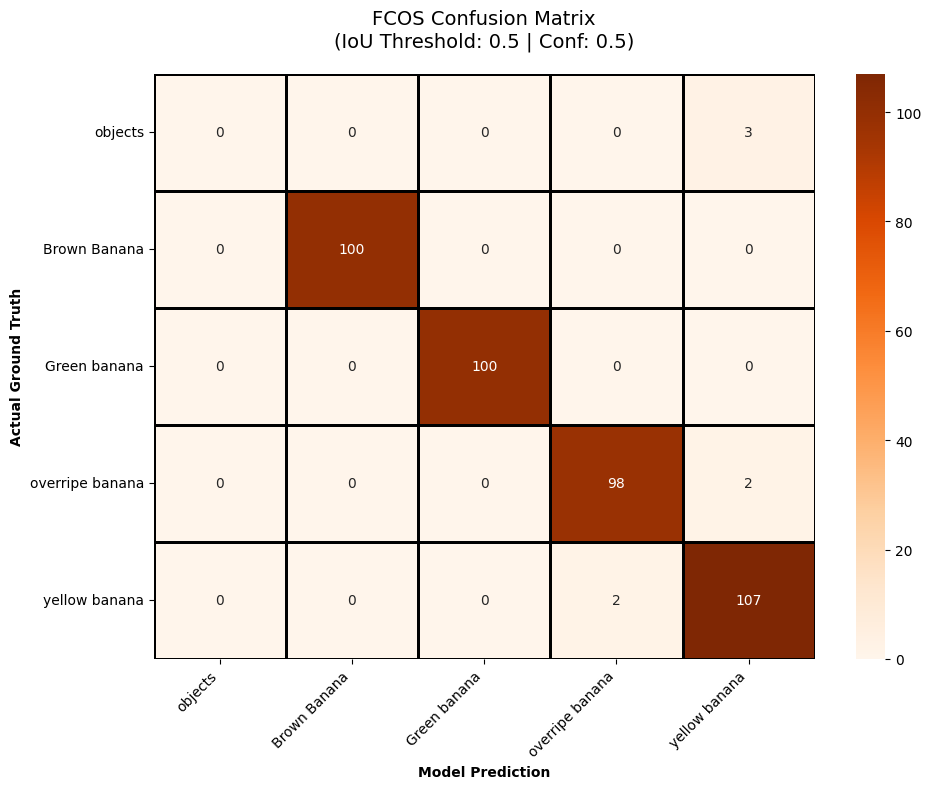

In [11]:
import json
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision.ops import box_iou
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# 0. Rebuild the id_to_name dictionary from your JSON
with open('valid/_annotations.coco.json', 'r') as f:
    coco_data = json.load(f)

id_to_name = {0: 'Background'}
for category in coco_data['categories']:
    id_to_name[category['id']] = category['name']

# 1. Setup Parameters and Metrics
iou_threshold = 0.5        
confidence_threshold = 0.5 
num_classes = len(id_to_name)

# Initialize mAP metric and Confusion Matrix
metric = MeanAveragePrecision(class_metrics=True)
conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

# Set FCOS to evaluation mode (CRITICAL)
fcos_model.eval()
print("Starting FCOS Evaluation on Validation Set... This may take a moment.")

# 2. Single Efficient Evaluation Loop
with torch.no_grad():
    for images, targets in data_loader_valid:
        images = list(img.to(device) for img in images)
        
        # Get FCOS predictions
        preds = fcos_model(images)
        
        # --- mAP Calculation Setup ---
        targets_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]
        preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in preds]
        metric.update(preds_cpu, targets_cpu)
        
        # --- Confusion Matrix Setup ---
        for target, pred in zip(targets, preds):
            gt_boxes = target['boxes'].cpu()
            gt_labels = target['labels'].cpu()
            
            pred_boxes = pred['boxes'].cpu()
            pred_labels = pred['labels'].cpu()
            pred_scores = pred['scores'].cpu()
            
            # Filter by confidence
            keep = pred_scores > confidence_threshold
            pred_boxes = pred_boxes[keep]
            pred_labels = pred_labels[keep]
            
            if len(gt_boxes) == 0 and len(pred_boxes) == 0:
                continue
                
            if len(gt_boxes) > 0 and len(pred_boxes) > 0:
                ious = box_iou(gt_boxes, pred_boxes)
            else:
                ious = torch.empty((len(gt_boxes), len(pred_boxes)))

            matched_preds = set()
            
            # Match Predictions to Ground Truths
            for gt_idx in range(len(gt_boxes)):
                gt_label = gt_labels[gt_idx].item()
                
                if len(pred_boxes) == 0:
                    conf_matrix[gt_label][0] += 1
                    continue
                
                valid_ious = ious[gt_idx].clone()
                valid_ious[list(matched_preds)] = -1 
                
                best_iou, best_pred_idx = valid_ious.max(dim=0)
                
                if best_iou > iou_threshold:
                    pred_label = pred_labels[best_pred_idx].item()
                    conf_matrix[gt_label][pred_label] += 1
                    matched_preds.add(best_pred_idx.item())
                else:
                    conf_matrix[gt_label][0] += 1
            
            # Unmatched predictions are False Positives
            for pred_idx in range(len(pred_boxes)):
                if pred_idx not in matched_preds:
                    pred_label = pred_labels[pred_idx].item()
                    conf_matrix[0][pred_label] += 1

# 3. Compute mAP Results
print("\nComputing final mAP scores...")
results = metric.compute()

print("\n" + "="*45)
print("     FCOS OVERALL PERFORMANCE METRICS")
print("="*45)
print(f"mAP (Mean Average Precision) : {results['map'].item():.4f}")
print(f"mAP at 50% IoU (Standard)    : {results['map_50'].item():.4f}")
print(f"mAP at 75% IoU (Strict)      : {results['map_75'].item():.4f}")
print(f"mAR (Mean Average Recall)    : {results['mar_100'].item():.4f}") 

# 4. Compute Precision, Recall, and F1-Score from the Matrix
print("\n" + "="*70)
print("               FCOS CLASS-WISE METRICS")
print("="*70)
print(f"{'Class Name':<20} | {'Precision':<12} | {'Recall':<12} | {'F1-Score':<12}")
print("-" * 70)

class_names = [id_to_name.get(i, f"Class {i}") for i in range(num_classes)]

for c in range(1, num_classes): 
    tp = conf_matrix[c, c]
    fp = np.sum(conf_matrix[:, c]) - tp
    fn = np.sum(conf_matrix[c, :]) - tp
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    print(f"{class_names[c]:<20} | {precision:<12.4f} | {recall:<12.4f} | {f1:<12.4f}")

print("=" * 70)

# 5. Plot the Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='black')

plt.title(f'FCOS Confusion Matrix\n(IoU Threshold: {iou_threshold} | Conf: {confidence_threshold})', pad=20, fontsize=14)
plt.ylabel('Actual Ground Truth', fontweight='bold')
plt.xlabel('Model Prediction', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Reading class names from test JSON...
JSON contains classes: {0: 'objects', 1: 'Brown Banana', 2: 'Green banana', 3: 'overripe banana', 4: 'yellow banana'}
Initializing blank FCOS model...
Loading trained weights from 'fcos_custom_weights.pth'...
Weights loaded successfully!
Setting up Test DataLoader...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Fetching a batch of test images and running inference...


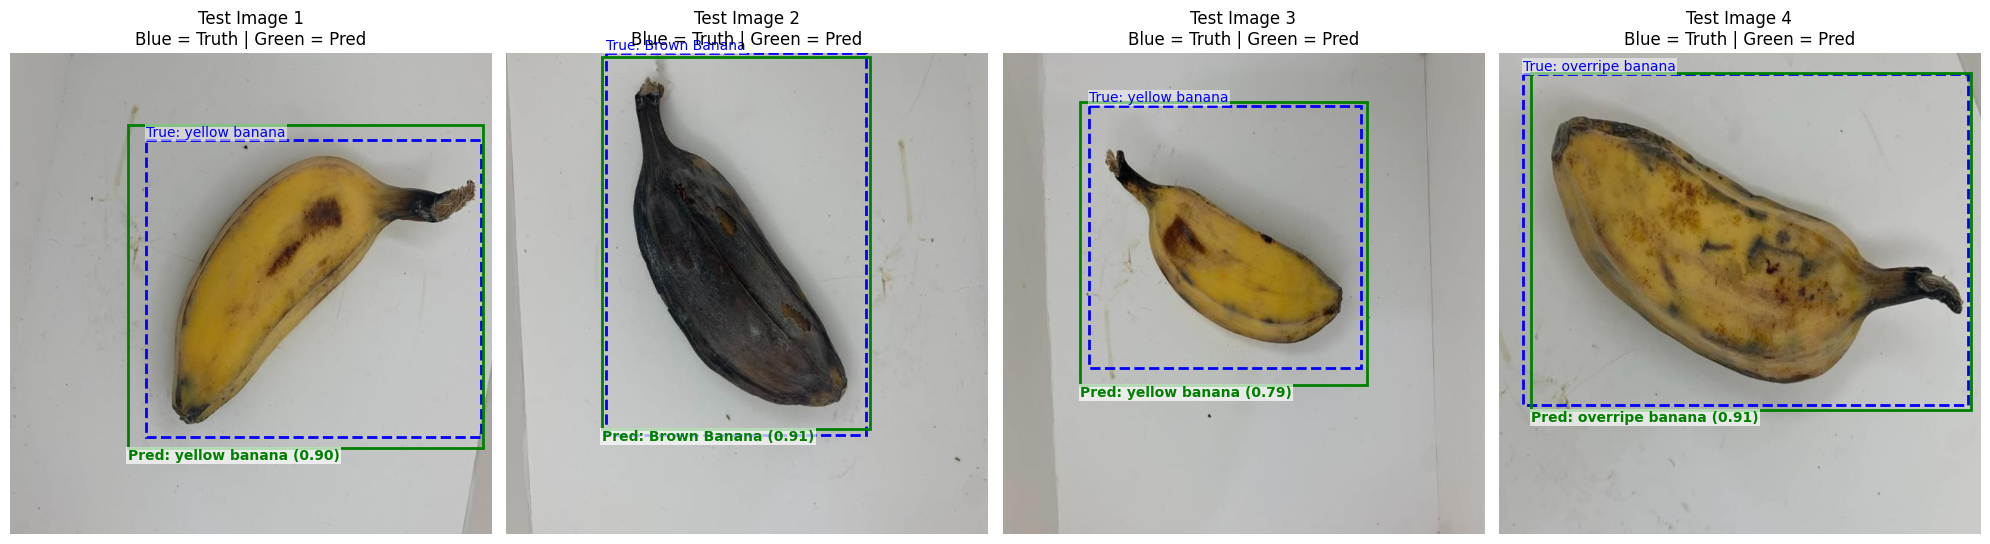

In [5]:
import os
import json
import torch
import numpy as np
import torchvision
from torchvision.models.detection import fcos_resnet50_fpn
from torchvision.models.detection.fcos import FCOSClassificationHead
from torchvision.transforms import functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import CocoDetection
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- 1. Setup Device ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
confidence_threshold = 0.5

# --- 2. Dynamically Load Classes from JSON ---
print("Reading class names from test JSON...")
with open('test/_annotations.coco.json', 'r') as f:
    coco_data = json.load(f)

class_names_dict = {0: 'Background'}
for cat in coco_data['categories']:
    class_names_dict[cat['id']] = cat['name']

print(f"JSON contains classes: {class_names_dict}")

# --- 3. Initialize the FCOS Model Architecture ---
print("Initializing blank FCOS model...")
fcos_model = fcos_resnet50_fpn(weights=None, weights_backbone=None)

# CRITICAL FIX: Force the model to have 6 classes to match the .pth weights exactly.
# Even if the test JSON only has 5 classes, the model head MUST match the trained weights.
NUM_CLASSES_WEIGHTS = 6 

in_channels = fcos_model.head.classification_head.conv[0].in_channels
num_anchors = fcos_model.head.classification_head.num_anchors
fcos_model.head.classification_head = FCOSClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=NUM_CLASSES_WEIGHTS
)

# --- 4. Load Custom Weights ---
print("Loading trained weights from 'fcos_custom_weights.pth'...")
state_dict = torch.load('fcos_custom_weights.pth', map_location=device)
fcos_model.load_state_dict(state_dict)
print("Weights loaded successfully!")

fcos_model.to(device)
fcos_model.eval()

# --- 5. Self-Contained Data Loader Setup ---
print("Setting up Test DataLoader...")

class CustomCocoTransform:
    def __call__(self, image, target):
        # Convert PIL image to PyTorch Tensor
        image = F.to_tensor(image)
        return image, target

def collate_fn(batch):
    return tuple(zip(*batch))

test_dataset = CocoDetection(
    root='test', 
    annFile='test/_annotations.coco.json',
    transforms=CustomCocoTransform()
)

data_loader_test = DataLoader(
    test_dataset, 
    batch_size=4, # Adjust batch size if needed
    shuffle=True, 
    collate_fn=collate_fn
)

# --- 6. Grab a batch and Run Inference ---
print("Fetching a batch of test images and running inference...")
dataiter = iter(data_loader_test)
images, targets = next(dataiter)

# Extract boxes and labels from the raw COCO targets for plotting
formatted_targets = []
for t in targets:
    boxes = torch.as_tensor([obj['bbox'] for obj in t], dtype=torch.float32)
    # COCO bbox format is [xmin, ymin, width, height], PyTorch needs [xmin, ymin, xmax, ymax]
    if len(boxes) > 0:
        boxes[:, 2] = boxes[:, 0] + boxes[:, 2]
        boxes[:, 3] = boxes[:, 1] + boxes[:, 3]
    labels = torch.as_tensor([obj['category_id'] for obj in t], dtype=torch.int64)
    formatted_targets.append({'boxes': boxes, 'labels': labels})

images_dev = list(img.to(device) for img in images)

with torch.no_grad():
    preds = fcos_model(images_dev)

# --- 7. Plotting Function ---
def plot_image_with_boxes(img_tensor, gt_target, pred_target, conf_thresh, ax, title=""):
    img_np = img_tensor.cpu().permute(1, 2, 0).numpy()
    img_np = np.clip(img_np, 0, 1)
    ax.imshow(img_np)
    
    # Draw Ground Truth Boxes (BLUE)
    gt_boxes = gt_target['boxes'].cpu().numpy()
    gt_labels = gt_target['labels'].cpu().numpy()
    for box, label in zip(gt_boxes, gt_labels):
        xmin, ymin, xmax, ymax = box
        width, height = xmax - xmin, ymax - ymin
        
        gt_name = class_names_dict.get(label, f"Class {label}")
        
        rect = patches.Rectangle((xmin, ymin), width, height, 
                                 linewidth=2, edgecolor='blue', facecolor='none', linestyle='--')
        ax.add_patch(rect)
        ax.text(xmin, ymin - 5, f'True: {gt_name}', color='blue', fontsize=10, 
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1))
        
    # Draw Predicted Boxes (GREEN)
    pred_boxes = pred_target['boxes'].cpu().numpy()
    pred_scores = pred_target['scores'].cpu().numpy()
    pred_labels = pred_target['labels'].cpu().numpy()
    
    for box, score, label in zip(pred_boxes, pred_scores, pred_labels):
        if score > conf_thresh:
            xmin, ymin, xmax, ymax = box
            width, height = xmax - xmin, ymax - ymin
            
            # If the model predicts class 5, it will gracefully fallback to "Class 5"
            label_name = class_names_dict.get(label, f"Class {label}")
            
            rect = patches.Rectangle((xmin, ymin), width, height, 
                                     linewidth=2, edgecolor='green', facecolor='none')
            ax.add_patch(rect)
            ax.text(xmin, ymax + 15, f'Pred: {label_name} ({score:.2f})', color='green', fontsize=10, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
            
    ax.axis('off')
    ax.set_title(title, fontsize=12)

# --- 8. Visualize the Batch ---
num_images = len(images)
fig, axes = plt.subplots(1, num_images, figsize=(20, 6))

if num_images == 1:
    axes = [axes]

for i in range(num_images):
    plot_image_with_boxes(
        images[i], 
        formatted_targets[i], 
        preds[i], 
        confidence_threshold, 
        axes[i], 
        title=f"Test Image {i+1}\nBlue = Truth | Green = Pred"
    )

plt.tight_layout()
plt.show()

In [6]:
import os
import json
import torch
import numpy as np
import torchvision
from torchvision.models.detection import fcos_resnet50_fpn
from torchvision.models.detection.fcos import FCOSClassificationHead
from torchvision.transforms import functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import CocoDetection
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- 1. Setup Device & Config ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
confidence_threshold = 0.5
output_base_dir = "saved_visualizations"
max_images_to_save = 20  # Set to None to process the entire test dataset

# --- 2. Dynamically Load Classes from JSON ---
print("Reading class names from test JSON...")
with open('test/_annotations.coco.json', 'r') as f:
    coco_data = json.load(f)

class_names_dict = {0: 'Background'}
for cat in coco_data['categories']:
    class_names_dict[cat['id']] = cat['name']

# --- 3. Initialize the FCOS Model Architecture ---
print("Initializing blank FCOS model...")
fcos_model = fcos_resnet50_fpn(weights=None, weights_backbone=None)

# Force the model to have 6 classes to match the .pth weights exactly.
NUM_CLASSES_WEIGHTS = 6 

in_channels = fcos_model.head.classification_head.conv[0].in_channels
num_anchors = fcos_model.head.classification_head.num_anchors
fcos_model.head.classification_head = FCOSClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=NUM_CLASSES_WEIGHTS
)

# --- 4. Load Custom Weights ---
print("Loading trained weights from 'fcos_custom_weights.pth'...")
state_dict = torch.load('fcos_custom_weights.pth', map_location=device)
fcos_model.load_state_dict(state_dict)
print("Weights loaded successfully!")

fcos_model.to(device)
fcos_model.eval()

# --- 5. Self-Contained Data Loader Setup ---
print("Setting up Test DataLoader...")

class CustomCocoTransform:
    def __call__(self, image, target):
        image = F.to_tensor(image)
        return image, target

def collate_fn(batch):
    return tuple(zip(*batch))

test_dataset = CocoDetection(
    root='test', 
    annFile='test/_annotations.coco.json',
    transforms=CustomCocoTransform()
)

# Batch size 1 is best for saving images individually
data_loader_test = DataLoader(
    test_dataset, 
    batch_size=1, 
    shuffle=True, 
    collate_fn=collate_fn
)

# --- 6. Process, Plot, and Save Loop ---
print(f"\nProcessing and saving up to {max_images_to_save if max_images_to_save else 'ALL'} images...")
print(f"Check the '{output_base_dir}' folder in your directory!\n")

for idx, (images, targets) in enumerate(data_loader_test):
    if max_images_to_save is not None and idx >= max_images_to_save:
        break
        
    img_tensor = images[0]
    target = targets[0]
    
    # Run Inference
    with torch.no_grad():
        preds = fcos_model([img_tensor.to(device)])[0]

    # Format Ground Truth
    gt_boxes = []
    gt_labels = []
    for obj in target:
        xmin, ymin, w, h = obj['bbox']
        gt_boxes.append([xmin, ymin, xmin + w, ymin + h])
        gt_labels.append(obj['category_id'])

    # Setup the plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    img_np = img_tensor.cpu().permute(1, 2, 0).numpy()
    img_np = np.clip(img_np, 0, 1)
    ax.imshow(img_np)
    
    # 6a. Draw Ground Truth Boxes (BLUE)
    for box, label in zip(gt_boxes, gt_labels):
        xmin, ymin, xmax, ymax = box
        width, height = xmax - xmin, ymax - ymin
        gt_name = class_names_dict.get(label, f"Class {label}")
        
        rect = patches.Rectangle((xmin, ymin), width, height, 
                                 linewidth=2, edgecolor='blue', facecolor='none', linestyle='--')
        ax.add_patch(rect)
        ax.text(xmin, ymin - 5, f'True: {gt_name}', color='blue', fontsize=10, 
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1))

    # 6b. Draw Predicted Boxes (GREEN) & Track Predicted Classes
    pred_boxes = preds['boxes'].cpu().numpy()
    pred_scores = preds['scores'].cpu().numpy()
    pred_labels = preds['labels'].cpu().numpy()
    
    predicted_class_names_in_image = set() # Keeps track of what the model saw
    
    for box, score, label in zip(pred_boxes, pred_scores, pred_labels):
        if score > confidence_threshold:
            xmin, ymin, xmax, ymax = box
            width, height = xmax - xmin, ymax - ymin
            label_name = class_names_dict.get(label, f"Class {label}")
            
            predicted_class_names_in_image.add(label_name)
            
            rect = patches.Rectangle((xmin, ymin), width, height, 
                                     linewidth=2, edgecolor='green', facecolor='none')
            ax.add_patch(rect)
            ax.text(xmin, ymax + 15, f'Pred: {label_name} ({score:.2f})', color='green', fontsize=10, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
            
    ax.axis('off')
    ax.set_title(f"Image ID: {idx}\nBlue = Truth | Green = Pred", fontsize=14)
    
    # 6c. Save the Figure into appropriate Class Folders
    # If it didn't find anything confident, put it in No_Detection
    if len(predicted_class_names_in_image) == 0:
        predicted_class_names_in_image.add("No_Detection")
        
    for class_name in predicted_class_names_in_image:
        # Create a safe folder name (removes spaces just in case)
        safe_folder_name = class_name.replace(" ", "_")
        class_dir = os.path.join(output_base_dir, safe_folder_name)
        os.makedirs(class_dir, exist_ok=True)
        
        # Save the file
        save_path = os.path.join(class_dir, f"test_img_{idx:03d}.png")
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0.1)
        
    # CRITICAL: Close the figure so your RAM doesn't fill up and crash the notebook
    plt.close(fig)

print(f"Finished! All visualizations have been saved inside the '{output_base_dir}' folder.")

Reading class names from test JSON...
Initializing blank FCOS model...
Loading trained weights from 'fcos_custom_weights.pth'...
Weights loaded successfully!
Setting up Test DataLoader...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!

Processing and saving up to 20 images...
Check the 'saved_visualizations' folder in your directory!

Finished! All visualizations have been saved inside the 'saved_visualizations' folder.
